# Probability Distributions and Random Variables

## Introduction

Probability distributions form the mathematical backbone of:

- statistics
- machine learning
- simulation systems
- Bayesian inference
- financial modeling
- scientific computing

This notebook develops the topic from first principles.

The progression is:

```text
Random Experiment
    -> Random Variable
    -> Probability Distribution
    -> Statistical Inference
```

Understanding this chain is critical for:

- data science
- ML engineering
- probabilistic modeling
- AI systems
- uncertainty quantification
- simulations

# 1. The Big Picture

## The Core Reasoning Chain

```mermaid
flowchart TD

A[Random Events]
    --> B[Random Variable]
    --> C[Possible Numerical Values]
    --> D[Probability Distribution]
    --> E[Inference and Prediction]
```

Examples:

| Real World Event | Random Variable |
|---|---|
| Coin flips | Number of heads |
| Height measurements | Height in cm |
| Website visits | Number of visitors |
| Manufacturing output | Defective units |
| Sensor readings | Temperature |

A probability distribution answers:

```text
How is probability allocated
across all possible outcomes?
```

# 2. Random Variables

## Definition

A random variable is:

```text
a numerical function of a random experiment
```

It maps outcomes to numbers.

## Example: Two Coin Flips

Experiment:

```text
Flip a fair coin twice
```

Possible outcomes:

$$
\{HH, HT, TH, TT\}
$$

Define random variable:

$$
X = \text{number of heads}
$$

| Outcome | HH | HT | TH | TT |
|---|---|---|---|---|
| $X$ | 2 | 1 | 1 | 0 |

# 3. Discrete vs Continuous Variables

| Discrete | Continuous |
|---|---|
| Countable values | Infinite values |
| Separate points | No gaps |
| Counting problems | Measurement problems |
| PMF | PDF |
| Example: number of customers | Example: customer waiting time |

## Discrete Example

A factory may produce:

```text
50, 100, 200 biscuits
```

but not:

```text
105.7 biscuits
```

## Continuous Example

A person's height may be:

```text
5.40
5.401
5.4011
5.40111
...
```

There are infinitely many values between any two measurements.

# 4. Probability Distributions

A probability distribution describes:

```text
how probability is spread
across possible values
```

Two major forms:

| Type | Mathematical Object |
|---|---|
| Discrete | PMF |
| Continuous | PDF |

# 5. The Allocation Mental Model

Imagine probability as:

```text
1 liter of water
```

A distribution determines how that water is allocated.

## Discrete Distribution

Water is poured into separate buckets:

```text
0   1   2   3
```

## Continuous Distribution

Water becomes a smooth mist over a continuous range.

# 6. Probability Mass Function (PMF)

For a discrete random variable:

$$
P(X = x_i) = p(x_i)
$$

Requirements:

$$
0 \leq p(x_i) \leq 1
$$

and:

$$
\sum_i p(x_i) = 1
$$

## Coin Flip Example

For two fair coin flips:

$$
P(X=0)=\frac14
$$

$$
P(X=1)=\frac12
$$

$$
P(X=2)=\frac14
$$

Check:

$$
\frac14 + \frac12 + \frac14 = 1
$$

# 7. Probability Density Function (PDF)

For continuous variables:

$$
P(a \leq X \leq b) = \int_a^b f(x)dx
$$

Requirements:

$$
f(x) \geq 0
$$

and:

$$
\int_{-\infty}^{\infty} f(x)dx = 1
$$

# 8. Why Exact Probability Is Zero for Continuous Variables

Question:

```text
What is the probability
that a person is exactly 170.000000 cm tall?
```

Answer:

$$
P(X = x) = 0
$$

for all continuous variables.

Why?

Because infinitely many possible values exist.

Continuous distributions assign probability to:

```text
intervals
```

not individual points.

# 9. Cumulative Distribution Function (CDF)

The CDF unifies discrete and continuous distributions.

$$
F(x)=P(X \leq x)
$$

## Discrete

$$
F(x)=\sum_{x_i \leq x} P(X=x_i)
$$

## Continuous

$$
F(x)=\int_{-\infty}^{x} f(t)dt
$$

Useful identity:

$$
P(X > x)=1-F(x)
$$

# 10. Bernoulli Distribution

The Bernoulli distribution models:

```text
one binary event
```

Examples:

- click / no-click
- pass / fail
- success / failure

Definition:

$$
P(X=x)=p^x(1-p)^{1-x}
$$

where:

$$
x \in \{0,1\}
$$

# 11. Binomial Distribution

The binomial distribution models:

```text
multiple Bernoulli trials
```

Formula:

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

where:

$$
\binom{n}{k}=\frac{n!}{k!(n-k)!}
$$

## Coin Flip Example

Flip a fair coin 10 times.

Probability of exactly 6 heads:

$$
P(X=6)=\binom{10}{6}\left(\frac12\right)^6\left(\frac12\right)^4
$$

$$
=210 \cdot \frac{1}{1024}
$$

$$
\approx 0.205
$$

# 12. Uniform Distribution

Every value in an interval is equally likely.

$$
f(x)=
\begin{cases}
\frac{1}{b-a} & a \leq x \leq b \\
0 & \text{otherwise}
\end{cases}
$$

# 13. Normal Distribution

The normal distribution is the famous bell curve.

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

Parameters:

| Parameter | Meaning |
|---|---|
| $\mu$ | mean |
| $\sigma$ | standard deviation |
| $\sigma^2$ | variance |

# 14. Why the Normal Distribution Appears Everywhere

The Central Limit Theorem states:

```text
sums of many small independent effects
tend toward normality
```

Examples:

- heights
- measurement errors
- exam scores
- manufacturing tolerances
- sensor noise

# 15. Required Python Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 16. Binomial Distribution Simulation

In [2]:
n_trials = 10
p_success = 0.5

k_values = np.arange(0, n_trials + 1)

pmf_values = stats.binom.pmf(
    k_values,
    n_trials,
    p_success
)

print("Binomial PMF")

for k, prob in zip(k_values, pmf_values):
    print(f"P(X={k}) = {prob:.4f}")

print(f"\nTotal Probability = {np.sum(pmf_values):.6f}")

Binomial PMF
P(X=0) = 0.0010
P(X=1) = 0.0098
P(X=2) = 0.0439
P(X=3) = 0.1172
P(X=4) = 0.2051
P(X=5) = 0.2461
P(X=6) = 0.2051
P(X=7) = 0.1172
P(X=8) = 0.0439
P(X=9) = 0.0098
P(X=10) = 0.0010

Total Probability = 1.000000


# 17. Monte Carlo Simulation

Monte Carlo simulation means:

```text
simulate randomness repeatedly
to estimate theoretical behavior
```

In [3]:
n_simulations = 100_000

simulated_heads = np.random.binomial(
    n_trials,
    p_success,
    n_simulations
)

simulated_counts = (
    np.bincount(simulated_heads)
    / n_simulations
)

# 18. Theory vs Simulation Visualization

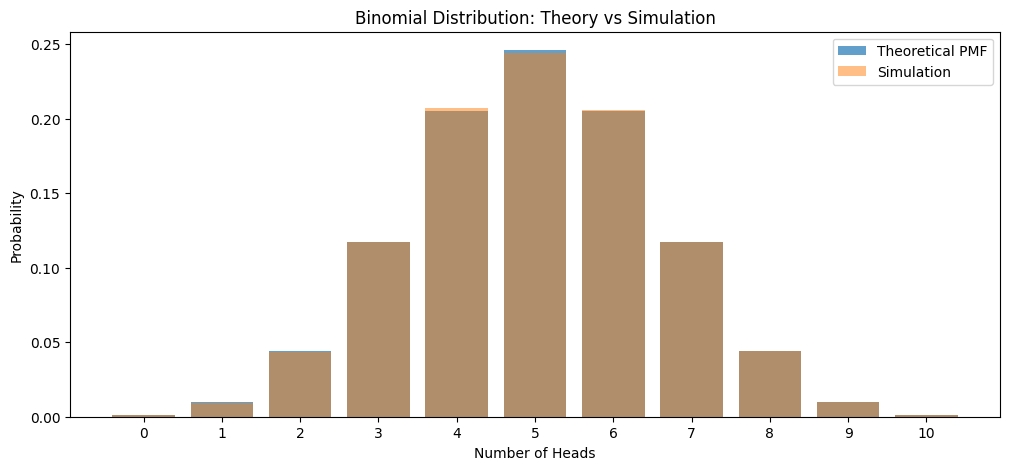

In [4]:
plt.figure(figsize=(12,5))

plt.bar(
    k_values,
    pmf_values,
    alpha=0.7,
    label='Theoretical PMF'
)

plt.bar(
    k_values,
    simulated_counts[:len(k_values)],
    alpha=0.5,
    label='Simulation'
)

plt.xlabel('Number of Heads')
plt.ylabel('Probability')
plt.title('Binomial Distribution: Theory vs Simulation')
plt.legend()
plt.xticks(k_values)

plt.show()

# 19. Normal Distribution Simulation

In [5]:
mu = 170
sigma = 10

x = np.linspace(
    mu - 4*sigma,
    mu + 4*sigma,
    1000
)

pdf_values = stats.norm.pdf(x, mu, sigma)

simulated_heights = np.random.normal(
    mu,
    sigma,
    100_000
)

# 20. PDF Visualization

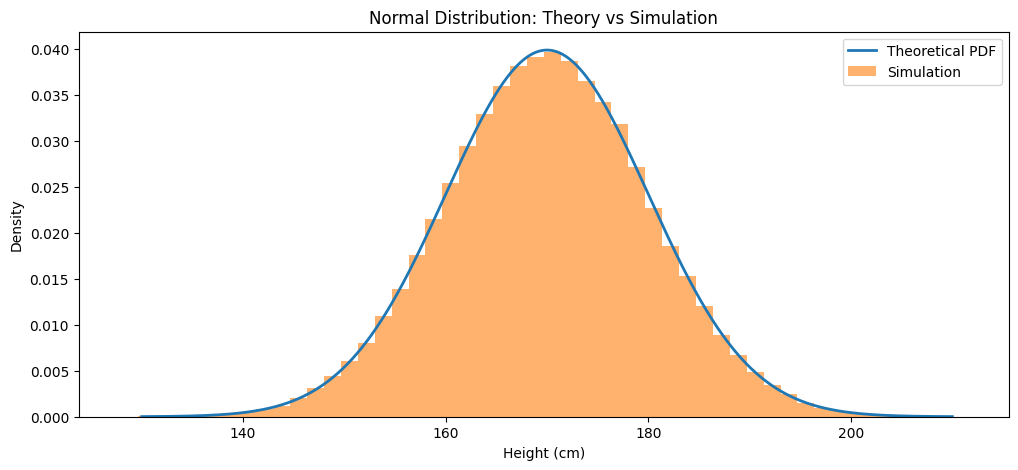

In [6]:
plt.figure(figsize=(12,5))

plt.plot(
    x,
    pdf_values,
    linewidth=2,
    label='Theoretical PDF'
)

plt.hist(
    simulated_heights,
    bins=50,
    density=True,
    alpha=0.6,
    label='Simulation'
)

plt.xlabel('Height (cm)')
plt.ylabel('Density')
plt.title('Normal Distribution: Theory vs Simulation')
plt.legend()

plt.show()

# 21. Why PDF Values Can Exceed 1

A PDF is:

```text
density
```

not probability.

Only:

```text
area under the curve
```

represents probability.

In [7]:
narrow_pdf = stats.norm.pdf(x, mu, 2)

print(f"Peak density = {np.max(narrow_pdf):.4f}")
print("PDF > 1 is valid because density is not probability.")

Peak density = 0.1994
PDF > 1 is valid because density is not probability.


# 22. Computing Interval Probabilities

In [8]:
probability = (
    stats.norm.cdf(180, mu, sigma)
    - stats.norm.cdf(160, mu, sigma)
)

print(f"P(160 < X < 180) = {probability:.4f}")

P(160 < X < 180) = 0.6827


# 23. Unified Visualization Flow

```mermaid
flowchart TD

A[Random Experiment]
    --> B{Type of Variable?}

B -->|Countable| C[Discrete Variable]
B -->|Continuous| D[Continuous Variable]

C --> E[PMF]
D --> F[PDF]

E --> G[Probability = Bar Height]
F --> H[Probability = Area Under Curve]

G --> I[CDF]
H --> J[CDF]
```

# 24. Engineering Applications

| Domain | Discrete Example | Continuous Example |
|---|---|---|
| E-commerce | Items in cart | Session duration |
| Manufacturing | Defects per batch | Product weight |
| Healthcare | Patients admitted | Blood pressure |
| Finance | Number of trades | Price movement |
| Machine Learning | Click/no-click | Feature distributions |

# 25. Machine Learning Connections

## Classification

Often modeled using:

- Bernoulli
- Binomial
- Categorical distributions

## Regression

Residual errors are often assumed normal.

## Naive Bayes

Models features using probability distributions.

## Anomaly Detection

Tail probabilities identify rare events.

# 26. Important Statistical Insight

Distributions are:

```text
models of uncertainty
```

not merely formulas.

A distribution captures:

- variability
- uncertainty
- randomness
- expected behavior
- rare events

# 27. Common Beginner Mistakes

| Mistake | Reality |
|---|---|
| PDF value > 1 means invalid probability | PDF is density |
| Continuous variables have exact probabilities | Exact probability is 0 |
| All distributions are normal | Many are skewed or heavy-tailed |
| 100 simulations are enough | Monte Carlo requires large samples |
| PMF and PDF behave identically | One sums, one integrates |

# 28. Performance and Computational Insight

Monte Carlo simulation scales with:

$$
O(n)
$$

where:

$$
n = \text{number of simulations}
$$

Larger simulation counts reduce variance but increase computation time.

# 29. Deep Mental Model

Think of probability distributions as:

```text
geometry of uncertainty
```

The shape of a distribution determines:

- where values cluster
- how spread out they are
- how likely extremes become
- how uncertainty propagates

# 30. Advanced Insight: Why Distributions Matter in AI

Modern AI systems fundamentally operate probabilistically.

Examples:

- LLM next-token prediction
- Bayesian neural networks
- probabilistic graphical models
- reinforcement learning policies
- uncertainty estimation

Probability distributions are foundational to:

```text
reasoning under uncertainty
```

# 31. Final Visualization Hierarchy

```mermaid
flowchart TD

A[Random Process]
    --> B[Random Variable]
    --> C[Distribution]
    --> D[Expectation and Variance]
    --> E[Inference]
    --> F[Prediction]
    --> G[Decision Making]
```

# Key Takeaways

## Core Concepts

1. Random variables convert uncertainty into numerical form
2. Probability distributions allocate probability across possible values
3. Discrete distributions use PMFs
4. Continuous distributions use PDFs
5. CDFs unify both frameworks
6. Monte Carlo simulation builds intuition and validates theory

## Most Important Mental Model

A probability distribution is:

```text
a map of uncertainty
```

## Most Important Engineering Insight

Modern ML and AI systems are fundamentally:

```text
probabilistic systems
```

not deterministic rule engines.

# Next Learning Roadmap

```text
Random Variables
    -> Probability Distributions
    -> Expectation and Variance
    -> Joint Distributions
    -> Conditional Probability
    -> Bayes Theorem
    -> Central Limit Theorem
    -> Statistical Inference
    -> Maximum Likelihood Estimation
    -> Bayesian Methods
```

# Recommended Libraries

| Library | Purpose |
|---|---|
| numpy.random | simulation |
| scipy.stats | PMFs, PDFs, CDFs |
| matplotlib | plotting |
| seaborn | statistical visualization |
| pandas | real-world data |
| statsmodels | statistical inference |
| pymc | Bayesian modeling |
| scikit-learn | machine learning |